# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** muhammad fikri
- **Email:** fikri.muhammad6659@gmail.com
- **ID Dicoding:** 4519796

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana perkembangan rata-rata penyewaan sepeda per bulan sepanjang 2011-2012 dan pola musimannya?
- Pertanyaan 2: Bagaimana pengaruh cuaca (weathersit) dan suhu (temp) terhadap jumlah penyewaan sepeda?

## Import Semua Packages/Library yang Digunakan

In [1]:
from pathlib import Path
import io
import zipfile
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## Data Wrangling

### Gathering Data

Tahap ini berfokus pada pengumpulan dataset Bike Sharing (day.csv dan hour.csv). Notebook akan:
- Mengutamakan pembacaan file lokal di folder `data/` jika sudah tersedia.
- Jika belum tersedia, notebook akan mengunduh dataset dari UCI dan mengekstrak file CSV yang dibutuhkan.
- Dataset harian digunakan untuk analisis tren dan dampak cuaca/suhu, sedangkan dataset per jam digunakan untuk analisis pola jam.


In [2]:
DATA_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00275/"
    "Bike-Sharing-Dataset.zip"
)

data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)

day_path = data_dir / "day.csv"
hour_path = data_dir / "hour.csv"

if (not day_path.exists()) or (not hour_path.exists()):
    legacy_dir = Path("submission/data")
    if (legacy_dir / "day.csv").exists() and (legacy_dir / "hour.csv").exists():
        day_path = legacy_dir / "day.csv"
        hour_path = legacy_dir / "hour.csv"
    else:
        with urlopen(DATA_URL) as response:
            zip_bytes = response.read()
        with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
            for target_name in ("day.csv", "hour.csv"):
                member = next(
                    (
                        n
                        for n in zf.namelist()
                        if n.endswith(f"/{target_name}") or n == target_name
                    ),
                    None,
                )
                if member is None:
                    continue
                with zf.open(member) as src, open(data_dir / target_name, "wb") as dst:
                    dst.write(src.read())
        day_path = data_dir / "day.csv"
        hour_path = data_dir / "hour.csv"

day_df = pd.read_csv(day_path)
hour_df = pd.read_csv(hour_path)

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset berhasil dimuat dari folder data proyek (day.csv dan hour.csv).
- Analisis utama difokuskan pada dataset harian untuk tren, sedangkan dataset per jam dipakai untuk pola jam.

### Assessing Data

Tahap assessing dilakukan untuk mengecek kualitas data sebelum dianalisis lebih lanjut, meliputi:
- Struktur data (tipe kolom dan jumlah baris) menggunakan `info()`.
- Missing value dan duplikasi untuk memastikan data bersih.
- Ringkasan statistik awal menggunakan `describe()` untuk memahami rentang nilai dan anomali.


In [3]:
print("Info dataset harian:")
print(day_df.info())

print("\nMissing values (harian):")
print(day_df.isna().sum().sort_values(ascending=False))

print("\nDuplikasi (harian):", day_df.duplicated().sum())

print("\nInfo dataset per jam:")
print(hour_df.info())

print("\nMissing values (per jam):")
print(hour_df.isna().sum().sort_values(ascending=False))

print("\nDuplikasi (per jam):", hour_df.duplicated().sum())

day_df.describe()

Info dataset harian:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

Missing values (harian):
instant       0
dteday        0
season   

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Tidak ditemukan missing value dan duplikasi pada dataset harian.
- Kolom tanggal (dteday) masih bertipe object sehingga perlu dikonversi ke datetime untuk analisis berbasis waktu.

### Cleaning Data

Pada tahap cleaning, dilakukan penyesuaian format dan pembuatan fitur turunan agar analisis lebih mudah:
- Konversi kolom tanggal (`dteday`) menjadi datetime.
- Mapping kode numerik musim dan cuaca menjadi label yang lebih mudah dipahami.
- Pembuatan fitur waktu seperti `year`, `month`, `year_month`, serta konversi suhu ke derajat Celsius.


In [4]:
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

season_map = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
weather_map = {
    1: "Clear/Partly Cloudy",
    2: "Mist/Cloudy",
    3: "Light Snow/Rain",
    4: "Heavy Rain/Ice",
}

day_df["season_label"] = day_df["season"].map(season_map)
day_df["weather_label"] = day_df["weathersit"].map(weather_map)

hour_df["season_label"] = hour_df["season"].map(season_map)
hour_df["weather_label"] = hour_df["weathersit"].map(weather_map)

day_df["year"] = day_df["yr"] + 2011
day_df["month"] = day_df["dteday"].dt.month
day_df["year_month"] = day_df["dteday"].dt.to_period("M").astype(str)
day_df["temp_c"] = day_df["temp"] * 41

hour_df["year"] = hour_df["yr"] + 2011
hour_df["temp_c"] = hour_df["temp"] * 41

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,...,windspeed,casual,registered,cnt,season_label,weather_label,year,month,year_month,temp_c
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,...,0.160446,331,654,985,Spring,Mist/Cloudy,2011,1,2011-01,14.110847
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,...,0.248539,131,670,801,Spring,Mist/Cloudy,2011,1,2011-01,14.902598
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,...,0.248309,120,1229,1349,Spring,Clear/Partly Cloudy,2011,1,2011-01,8.050924
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,...,0.160296,108,1454,1562,Spring,Clear/Partly Cloudy,2011,1,2011-01,8.200000
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,...,0.186900,82,1518,1600,Spring,Clear/Partly Cloudy,2011,1,2011-01,9.305237


**Insight:**
- Tanggal sudah menjadi datetime sehingga bisa dibuat agregasi bulanan/harian dengan lebih mudah.
- Label musim dan cuaca membantu interpretasi visualisasi (lebih mudah dipahami dibanding angka kode).

## Exploratory Data Analysis (EDA)

Tahap EDA bertujuan untuk memahami pola umum pada data sebelum menjawab pertanyaan bisnis, seperti:
- Melihat ringkasan statistik untuk memahami sebaran dan rentang nilai.
- Mengecek korelasi antar variabel numerik sebagai indikasi hubungan awal.
- Mengidentifikasi variabel yang paling relevan untuk visualisasi explanatory.


### Ringkasan Statistik, Distribusi, dan Korelasi

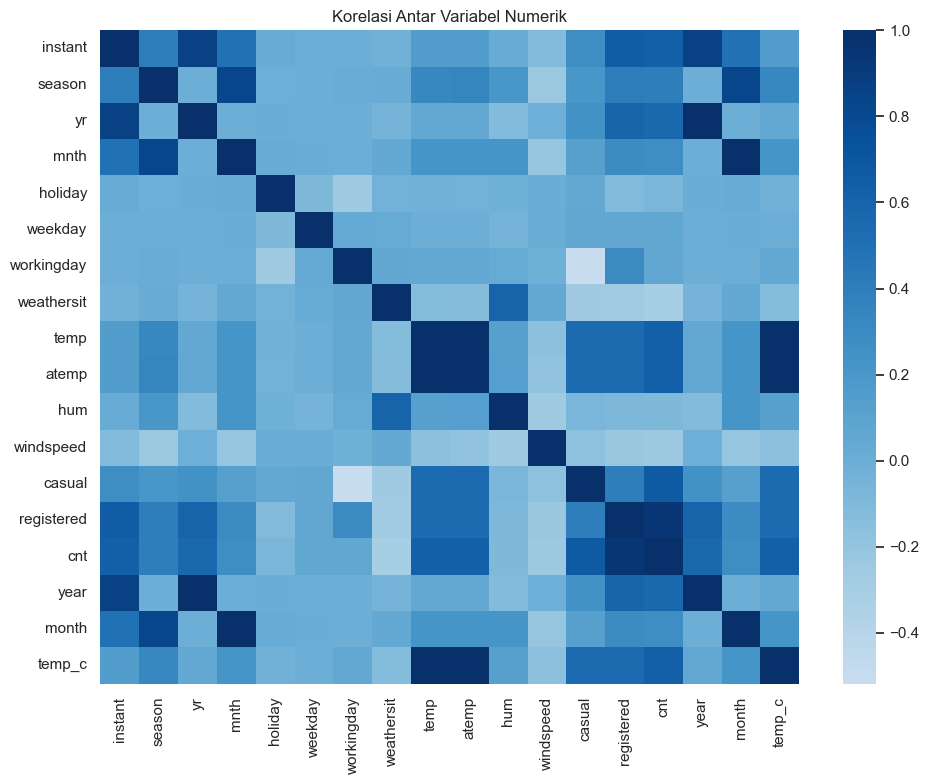

In [5]:
day_df.describe()

corr = day_df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="Blues", center=0)
plt.title("Korelasi Antar Variabel Numerik")
plt.tight_layout()
plt.show()

**Insight:**
- Data memiliki 731 baris (2011-2012) dengan kombinasi fitur kalender (bulan/hari kerja) dan cuaca.
- Variabel cnt menjadi target utama untuk mengevaluasi tren serta pengaruh cuaca dan suhu.

### Agregasi untuk Menjawab Pertanyaan Bisnis

#### Pertanyaan 1 (Tren bulanan & musiman)
Agregasi berikut membantu melihat tren rata-rata dan total penyewaan secara lebih terstruktur sebelum masuk ke visualisasi.

In [6]:
from IPython.display import display

monthly_agg_df = (
    day_df.groupby(["year", "month"], as_index=False)
    .agg(days=("cnt", "size"), avg_cnt=("cnt", "mean"), total_cnt=("cnt", "sum"))
    .sort_values(["year", "month"])
)
monthly_agg_df["avg_cnt"] = monthly_agg_df["avg_cnt"].round(2)
display(monthly_agg_df)

monthly_pivot_df = monthly_agg_df.pivot(index="month", columns="year", values="avg_cnt").dropna()
monthly_pivot_df["pct_change_2012_vs_2011"] = (
    (monthly_pivot_df[2012] / monthly_pivot_df[2011] - 1) * 100
)
display(monthly_pivot_df.round(2))

top_month_df = (
    monthly_agg_df.sort_values(["year", "avg_cnt"], ascending=[True, False])
    .groupby("year")
    .head(3)
)
display(top_month_df[["year", "month", "avg_cnt", "total_cnt"]])

season_agg_df = (
    day_df.groupby(["year", "season_label"], as_index=False)
    .agg(days=("cnt", "size"), avg_cnt=("cnt", "mean"), total_cnt=("cnt", "sum"))
)
season_agg_df["avg_cnt"] = season_agg_df["avg_cnt"].round(2)
display(season_agg_df.sort_values(["year", "avg_cnt"], ascending=[True, False]))

,year,month,days,avg_cnt,total_cnt
0,2011,1,31,1231.90,38189
1,2011,2,28,1721.96,48215
2,2011,3,31,2065.97,64045
3,2011,4,30,3162.33,94870
4,2011,5,31,4381.32,135821
5,2011,6,30,4783.73,143512
6,2011,7,31,4559.39,141341
7,2011,8,31,4409.39,136691
8,2011,9,30,4247.27,127418
9,2011,10,31,3984.23,123511


year,2011,2012,pct_change_2012_vs_2011
month,,,
1,1231.90,3120.77,153.33
2,1721.96,3556.45,106.53
3,2065.97,5318.55,157.44
4,3162.33,5807.47,83.65
5,4381.32,6318.23,44.21
6,4783.73,6761.00,41.33
7,4559.39,6567.97,44.05
8,4409.39,6919.45,56.93
9,4247.27,7285.77,71.54


,year,month,avg_cnt,total_cnt
5,2011,6,4783.73,143512
6,2011,7,4559.39,141341
7,2011,8,4409.39,136691
20,2012,9,7285.77,218573
19,2012,8,6919.45,214503
17,2012,6,6761.00,202830


,year,season_label,days,avg_cnt,total_cnt
0,2011,Fall,94,4464.36,419650
2,2011,Summer,92,3775.17,347316
3,2011,Winter,89,3664.46,326137
1,2011,Spring,90,1666.67,150000
4,2012,Fall,94,6824.24,641479
6,2012,Summer,92,6209.49,571273
7,2012,Winter,89,5791.87,515476
5,2012,Spring,91,3531.30,321348


#### Pertanyaan 2 (Cuaca & suhu)
Agregasi berikut merangkum perbedaan rata-rata penyewaan berdasarkan kategori cuaca serta kategori suhu.

In [7]:
from IPython.display import display

weather_agg_df = (
    day_df.groupby("weather_label", as_index=False)
    .agg(days=("cnt", "size"), avg_cnt=("cnt", "mean"), median_cnt=("cnt", "median"))
)
clear_avg = weather_agg_df.loc[
    weather_agg_df["weather_label"] == "Clear/Partly Cloudy", "avg_cnt"
].squeeze()
weather_agg_df["pct_vs_clear"] = (weather_agg_df["avg_cnt"] / clear_avg - 1) * 100
weather_agg_df = weather_agg_df.sort_values("avg_cnt", ascending=False)
display(weather_agg_df.round(2))

temp_bins = [-0.1, 10, 20, 30, 41]
temp_labels = ["<=10°C", "10–20°C", "20–30°C", ">30°C"]
day_df["temp_bin"] = pd.cut(day_df["temp_c"], bins=temp_bins, labels=temp_labels)

temp_agg_df = (
    day_df.groupby("temp_bin", as_index=False, observed=False)
    .agg(days=("cnt", "size"), avg_cnt=("cnt", "mean"), median_cnt=("cnt", "median"))
    .sort_values("avg_cnt", ascending=False)
)
display(temp_agg_df.round(2))

,weather_label,days,avg_cnt,median_cnt,pct_vs_clear
0,Clear/Partly Cloudy,463,4876.79,4844.0,0.00
2,Mist/Cloudy,247,4035.86,4040.0,-17.24
1,Light Snow/Rain,21,1803.29,1817.0,-63.02


,temp_bin,days,avg_cnt,median_cnt
2,20–30°C,300,5661.69,5353.5
3,>30°C,72,5409.96,5000.0
1,10–20°C,299,3692.27,3649.0
0,<=10°C,60,1677.77,1529.5


## Visualization & Explanatory Analysis

Pada tahap ini, visualisasi dibuat untuk menjawab pertanyaan bisnis secara jelas (explanatory), yaitu:
- Membandingkan tren rata-rata penyewaan antar waktu (bulanan) dan melihat pola musiman.
- Menunjukkan bagaimana cuaca dan suhu berkaitan dengan jumlah penyewaan.
Output visualisasi diikuti ringkasan insight yang langsung mengaitkan temuan dengan pertanyaan bisnis.


### Pertanyaan 1:
Bagaimana perkembangan rata-rata penyewaan sepeda per bulan sepanjang 2011-2012 dan pola musimannya?

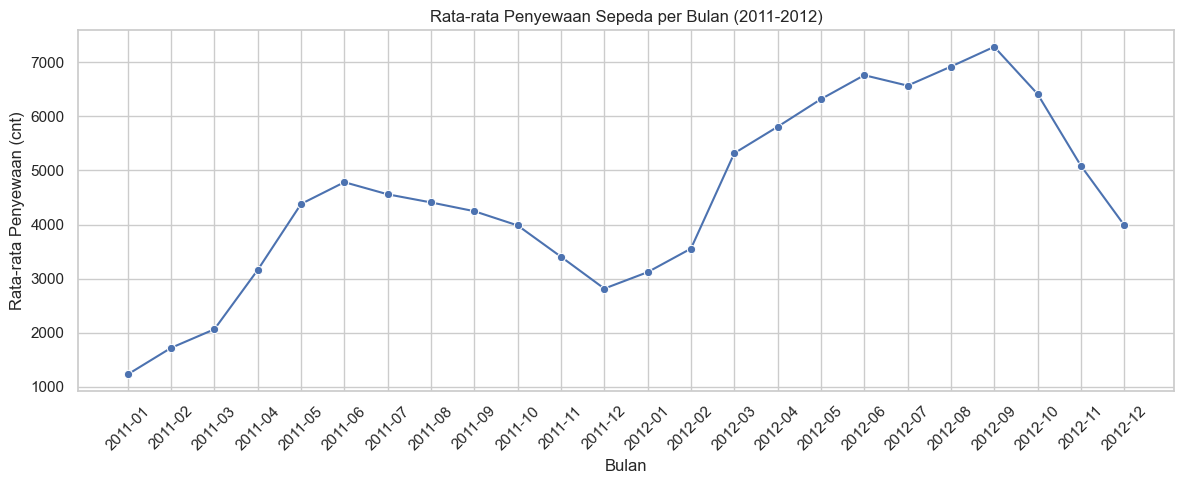

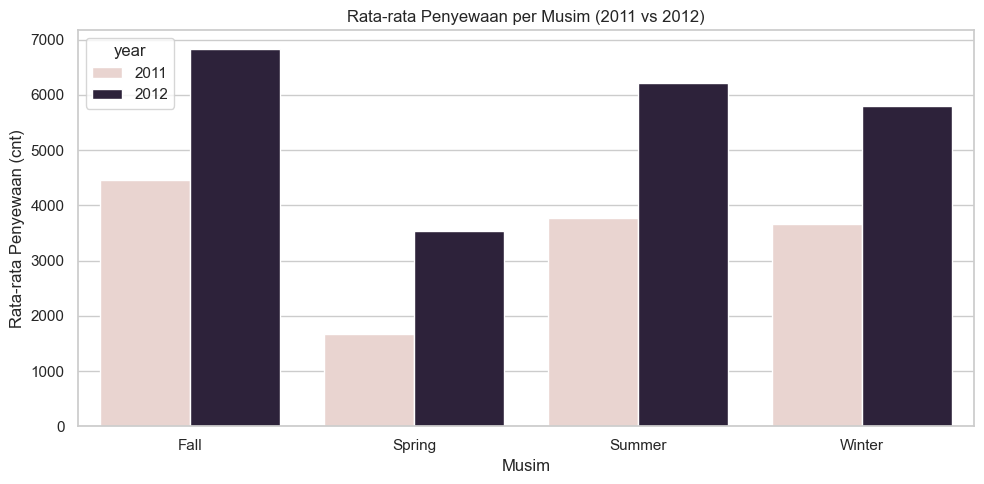

In [8]:
monthly_avg_df = (
    day_df.groupby(["year_month", "year"], as_index=False)
    .agg(avg_cnt=("cnt", "mean"), total_cnt=("cnt", "sum"))
    .sort_values("year_month")
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_avg_df, x="year_month", y="avg_cnt", marker="o")
plt.title("Rata-rata Penyewaan Sepeda per Bulan (2011-2012)")
plt.xlabel("Bulan")
plt.ylabel("Rata-rata Penyewaan (cnt)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

season_avg_df = (
    day_df.groupby(["year", "season_label"], as_index=False)
    .agg(avg_cnt=("cnt", "mean"))
)

plt.figure(figsize=(10, 5))
sns.barplot(data=season_avg_df, x="season_label", y="avg_cnt", hue="year")
plt.title("Rata-rata Penyewaan per Musim (2011 vs 2012)")
plt.xlabel("Musim")
plt.ylabel("Rata-rata Penyewaan (cnt)")
plt.tight_layout()
plt.show()

### Pertanyaan 2:
Bagaimana pengaruh cuaca (weathersit) dan suhu (temp) terhadap jumlah penyewaan sepeda?

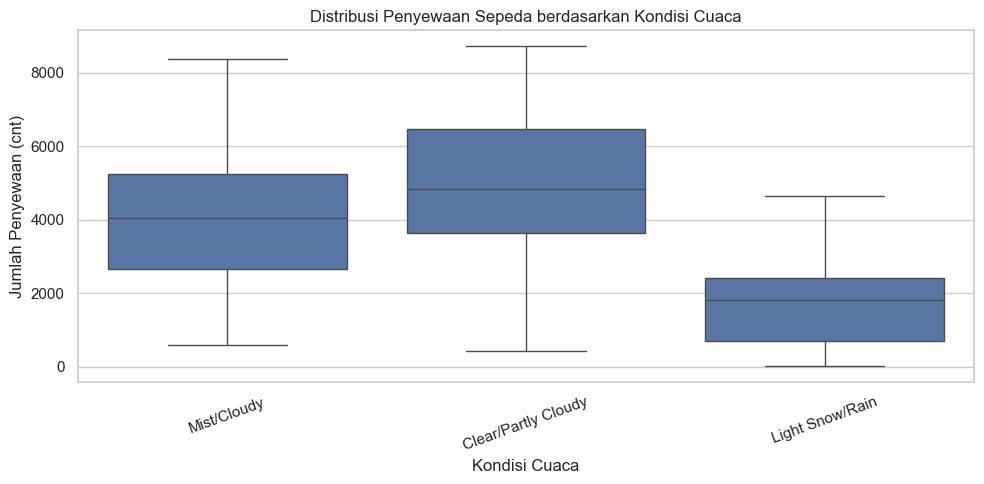

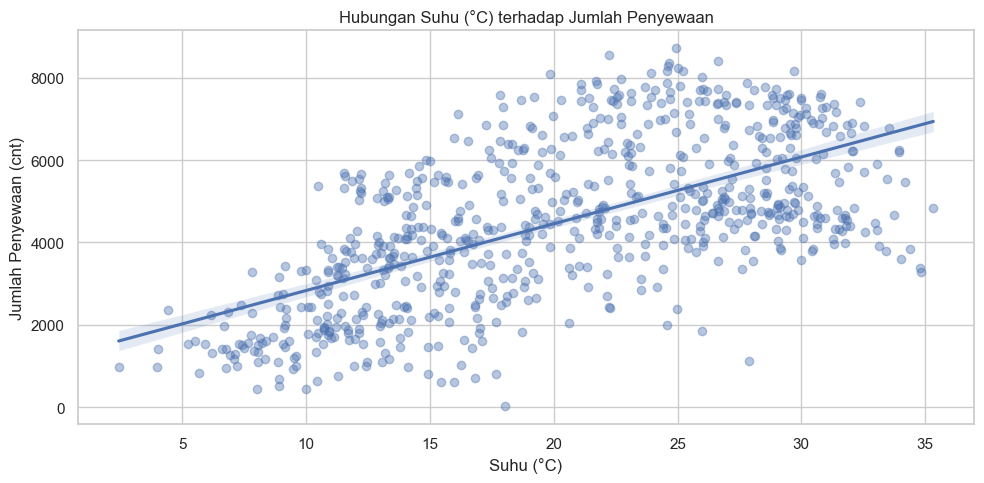

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=day_df, x="weather_label", y="cnt")
plt.title("Distribusi Penyewaan Sepeda berdasarkan Kondisi Cuaca")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Jumlah Penyewaan (cnt)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.regplot(data=day_df, x="temp_c", y="cnt", scatter_kws={"alpha": 0.4})
plt.title("Hubungan Suhu (°C) terhadap Jumlah Penyewaan")
plt.xlabel("Suhu (°C)")
plt.ylabel("Jumlah Penyewaan (cnt)")
plt.tight_layout()
plt.show()

**Insight:**
- Rata-rata penyewaan cenderung meningkat dari 2011 ke 2012 dan memiliki pola musiman yang jelas.
- Kondisi cuaca yang lebih baik dan suhu yang lebih hangat berkorelasi dengan peningkatan jumlah penyewaan.

## Analisis Lanjutan (Opsional)

Bagian opsional ini berisi teknik analisis lanjutan tanpa algoritma machine learning, misalnya:
- **Manual grouping**: mengelompokkan jam penggunaan menjadi kategori waktu (pagi/siang/sore/malam) untuk membandingkan pola penyewaan.
- **Binning (pd.cut)**: membagi variabel kontinu (contoh suhu) ke beberapa kategori agar interpretasi lebih mudah.


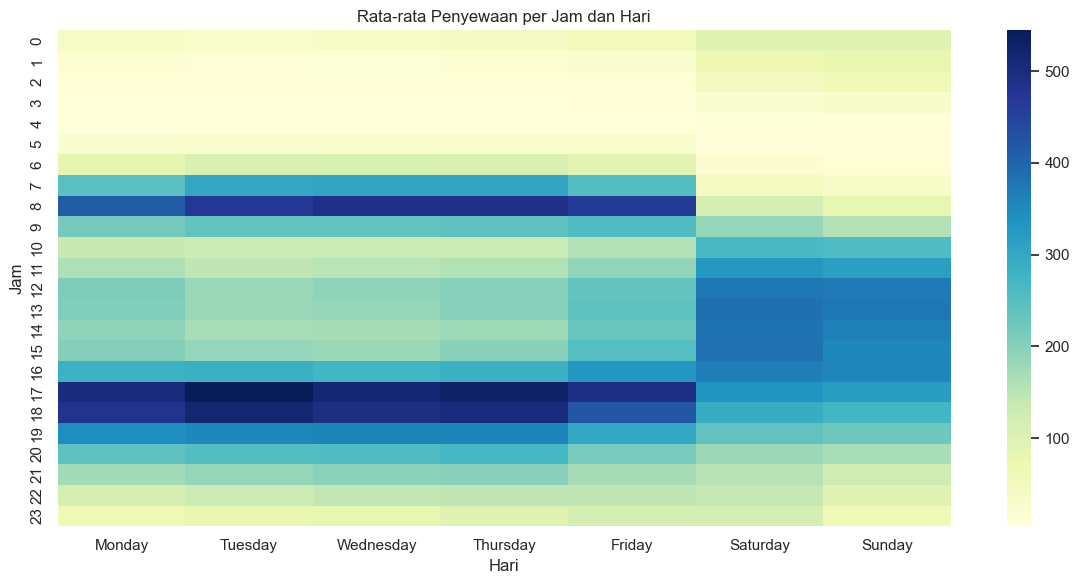

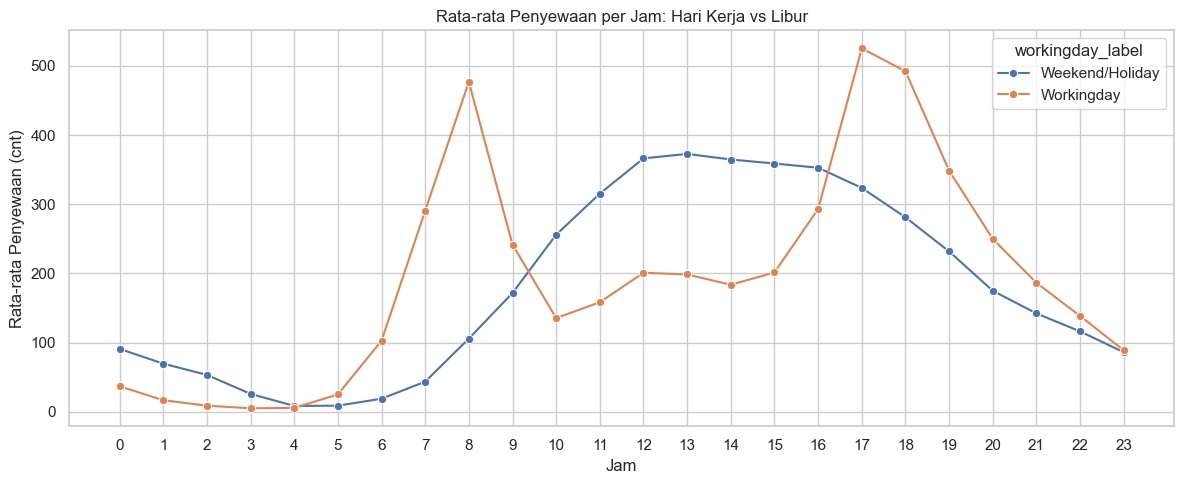

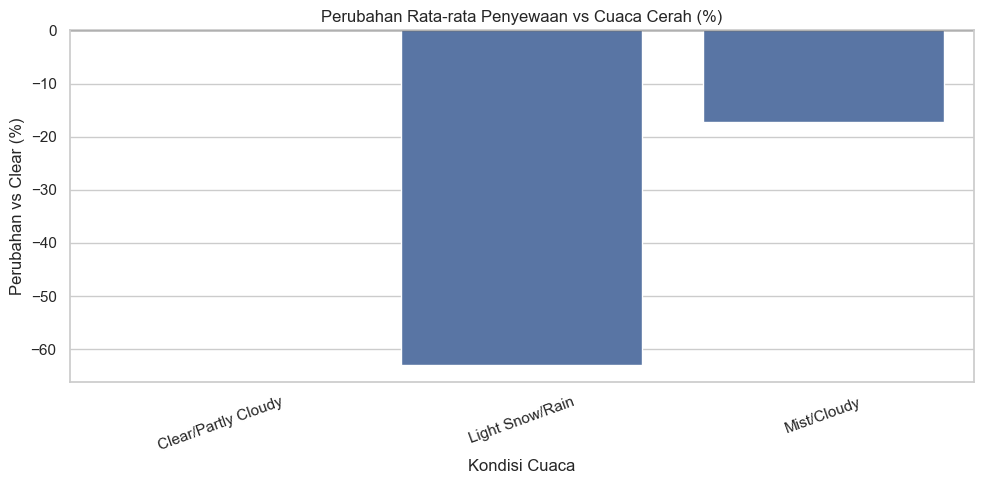

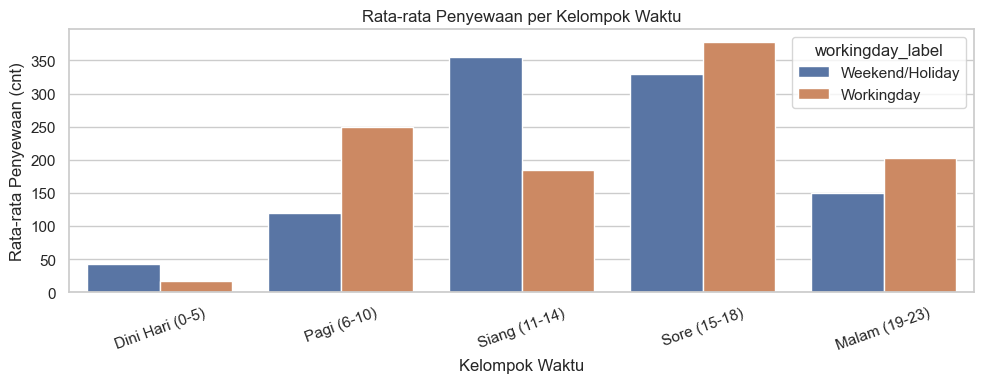

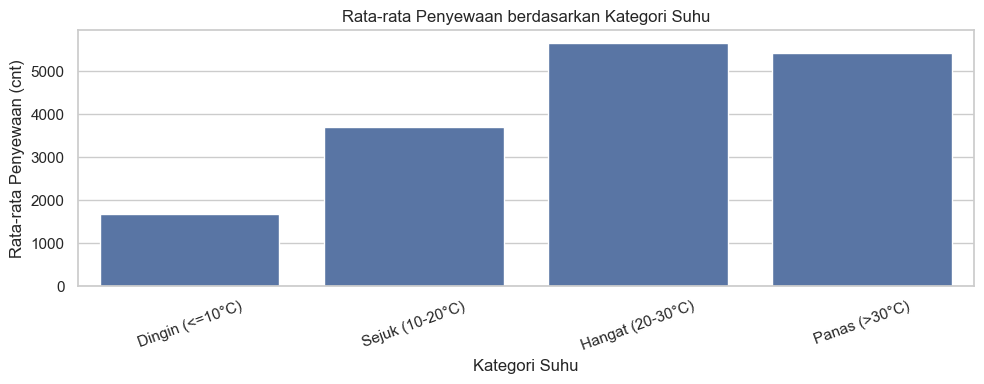

In [10]:
weekday_map = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
}

hour_df["weekday_label"] = hour_df["weekday"].map(weekday_map)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

heatmap_df = hour_df.pivot_table(
    index="hr", columns="weekday_label", values="cnt", aggfunc="mean"
).reindex(columns=weekday_order)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_df, cmap="YlGnBu")
plt.title("Rata-rata Penyewaan per Jam dan Hari")
plt.xlabel("Hari")
plt.ylabel("Jam")
plt.tight_layout()
plt.show()

hourly_workday_df = (
    hour_df.groupby(["hr", "workingday"], as_index=False)
    .agg(avg_cnt=("cnt", "mean"))
    .sort_values(["workingday", "hr"])
)
hourly_workday_df["workingday_label"] = hourly_workday_df["workingday"].map(
    {0: "Weekend/Holiday", 1: "Workingday"}
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=hourly_workday_df,
    x="hr",
    y="avg_cnt",
    hue="workingday_label",
    marker="o",
)
plt.title("Rata-rata Penyewaan per Jam: Hari Kerja vs Libur")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan (cnt)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

peak_hours_df = (
    hourly_workday_df.sort_values("avg_cnt", ascending=False)
    .groupby("workingday_label", as_index=False)
    .head(3)
    .sort_values(["workingday_label", "avg_cnt"], ascending=[True, False])
)
peak_hours_df[["workingday_label", "hr", "avg_cnt"]]

weather_impact_df = day_df.groupby("weather_label", as_index=False).agg(avg_cnt=("cnt", "mean"))
clear_avg = weather_impact_df.loc[
    weather_impact_df["weather_label"] == "Clear/Partly Cloudy", "avg_cnt"
].squeeze()
weather_impact_df["pct_vs_clear"] = (weather_impact_df["avg_cnt"] / clear_avg - 1) * 100

plt.figure(figsize=(10, 5))
sns.barplot(data=weather_impact_df, x="weather_label", y="pct_vs_clear")
plt.axhline(0, color="black", linewidth=1)
plt.title("Perubahan Rata-rata Penyewaan vs Cuaca Cerah (%)")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Perubahan vs Clear (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

time_bins = [-0.1, 5, 10, 14, 18, 23]
time_labels = [
    "Dini Hari (0-5)",
    "Pagi (6-10)",
    "Siang (11-14)",
    "Sore (15-18)",
    "Malam (19-23)",
]
hour_df["time_group"] = pd.cut(
    hour_df["hr"], bins=time_bins, labels=time_labels, include_lowest=True
)
time_group_avg_df = (
    hour_df.groupby(["time_group", "workingday"], as_index=False, observed=False)
    .agg(avg_cnt=("cnt", "mean"))
    .sort_values(["time_group", "workingday"])
)
time_group_avg_df["workingday_label"] = time_group_avg_df["workingday"].map(
    {0: "Weekend/Holiday", 1: "Workingday"}
)
time_group_avg_df

plt.figure(figsize=(10, 4))
sns.barplot(data=time_group_avg_df, x="time_group", y="avg_cnt", hue="workingday_label")
plt.title("Rata-rata Penyewaan per Kelompok Waktu")
plt.xlabel("Kelompok Waktu")
plt.ylabel("Rata-rata Penyewaan (cnt)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

temp_bins = [-0.1, 10, 20, 30, 41]
temp_labels = [
    "Dingin (<=10°C)",
    "Sejuk (10-20°C)",
    "Hangat (20-30°C)",
    "Panas (>30°C)",
]
day_df["temp_bin"] = pd.cut(day_df["temp_c"], bins=temp_bins, labels=temp_labels)
temp_bin_avg_df = day_df.groupby("temp_bin", as_index=False, observed=False).agg(avg_cnt=("cnt", "mean"))
temp_bin_avg_df

plt.figure(figsize=(10, 4))
sns.barplot(data=temp_bin_avg_df, x="temp_bin", y="avg_cnt")
plt.title("Rata-rata Penyewaan berdasarkan Kategori Suhu")
plt.xlabel("Kategori Suhu")
plt.ylabel("Rata-rata Penyewaan (cnt)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Conclusion

### Ringkasan Insight

In [11]:
from IPython.display import Markdown, display

year_agg_df = (
    day_df.groupby("year", as_index=False)
    .agg(avg_cnt=("cnt", "mean"), total_cnt=("cnt", "sum"))
    .sort_values("year")
)

avg_2011 = year_agg_df.loc[year_agg_df["year"] == 2011, "avg_cnt"].iloc[0]
avg_2012 = year_agg_df.loc[year_agg_df["year"] == 2012, "avg_cnt"].iloc[0]
growth_pct = (avg_2012 / avg_2011 - 1) * 100

monthly_avg_df = (
    day_df.groupby(["year", "month"], as_index=False)
    .agg(avg_cnt=("cnt", "mean"))
    .sort_values(["year", "month"])
)

peak_month_lines = []
for yr in [2011, 2012]:
    row = (
        monthly_avg_df[monthly_avg_df["year"] == yr]
        .sort_values("avg_cnt", ascending=False)
        .iloc[0]
    )
    peak_month_lines.append(
        f"{yr}: bulan {int(row['month'])} (rata-rata {row['avg_cnt']:.0f}/hari)"
    )

season_avg_df = (
    day_df.groupby(["year", "season_label"], as_index=False)
    .agg(avg_cnt=("cnt", "mean"))
    .sort_values(["year", "avg_cnt"], ascending=[True, False])
)
top_season_lines = []
for yr in [2011, 2012]:
    row = season_avg_df[season_avg_df["year"] == yr].iloc[0]
    top_season_lines.append(
        f"{yr}: {row['season_label']} (rata-rata {row['avg_cnt']:.0f}/hari)"
    )

weather_avg_df = (
    day_df.groupby("weather_label", as_index=False)
    .agg(days=("cnt", "size"), avg_cnt=("cnt", "mean"))
)
clear_avg = weather_avg_df.loc[
    weather_avg_df["weather_label"] == "Clear/Partly Cloudy", "avg_cnt"
].iloc[0]
weather_avg_df["pct_vs_clear"] = (weather_avg_df["avg_cnt"] / clear_avg - 1) * 100
weather_avg_df = weather_avg_df.sort_values("avg_cnt", ascending=False)

weather_lines = []
for _, r in weather_avg_df.iterrows():
    weather_lines.append(
        f"{r['weather_label']}: {r['avg_cnt']:.0f}/hari ({r['pct_vs_clear']:.1f}% vs cerah, n={int(r['days'])} hari)"
    )

temp_bins = [-0.1, 10, 20, 30, 41]
temp_labels = ["<=10°C", "10–20°C", "20–30°C", ">30°C"]
day_df["temp_bin"] = pd.cut(day_df["temp_c"], bins=temp_bins, labels=temp_labels)
temp_avg_df = (
    day_df.groupby("temp_bin", as_index=False, observed=False)
    .agg(days=("cnt", "size"), avg_cnt=("cnt", "mean"))
    .sort_values("avg_cnt", ascending=False)
)
best_temp = temp_avg_df.iloc[0]

conclusion_md = "\n".join(
    [
        f"- Secara keseluruhan, rata-rata penyewaan harian meningkat dari {avg_2011:.0f} (2011) menjadi {avg_2012:.0f} (2012) atau sekitar {growth_pct:.1f}%.",
        "- Pola musiman terlihat konsisten dengan puncak rata-rata bulanan: " + "; ".join(peak_month_lines) + ".",
        "- Musim dengan rata-rata penyewaan tertinggi per tahun: " + "; ".join(top_season_lines) + ".",
        "- Dampak cuaca (dibanding cuaca cerah): " + "; ".join(weather_lines) + ".",
        f"- Kategori suhu dengan rata-rata penyewaan tertinggi adalah {best_temp['temp_bin']} (rata-rata {best_temp['avg_cnt']:.0f}/hari, n={int(best_temp['days'])} hari).",
    ]
)

display(Markdown(conclusion_md))

- Secara keseluruhan, rata-rata penyewaan harian meningkat dari 3406 (2011) menjadi 5600 (2012) atau sekitar 64.4%.
- Pola musiman terlihat konsisten dengan puncak rata-rata bulanan: 2011: bulan 6 (rata-rata 4784/hari); 2012: bulan 9 (rata-rata 7286/hari).
- Musim dengan rata-rata penyewaan tertinggi per tahun: 2011: Fall (rata-rata 4464/hari); 2012: Fall (rata-rata 6824/hari).
- Dampak cuaca (dibanding cuaca cerah): Clear/Partly Cloudy: 4877/hari (0.0% vs cerah, n=463 hari); Mist/Cloudy: 4036/hari (-17.2% vs cerah, n=247 hari); Light Snow/Rain: 1803/hari (-63.0% vs cerah, n=21 hari).
- Kategori suhu dengan rata-rata penyewaan tertinggi adalah 20–30°C (rata-rata 5662/hari, n=300 hari).